In [18]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from pathlib import Path
from lightkurve import KeplerLightCurveFile
import math
from gatspy.periodic import *

In [19]:
pwd

'/Users/tmishra/Downloads/roto/roto2.0/roto-project'

In [22]:
path_to_files = "/Users/tmishra/Downloads/roto/roto2.0/roto-project/MAST_2025-10-23T2232/MAST_2025-10-23T2232/Kepler/kplr005110407_lc_Q001111011101110111/kplr005110407_lc_Q001111011101110111_all_files/005110407"

In [23]:
folder = Path(path_to_files)

# find all .fits files in the folder (non-recursive)
fits_files = list(folder.glob("*.fits"))

In [24]:
len(fits_files)

13

In [25]:
light_curves= []
for file in fits_files:
    lcfile = KeplerLightCurveFile(file)
    lc = lcfile.PDCSAP_FLUX.remove_nans()
    light_curves.append(lc)

/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.

In [26]:
len(light_curves)

13

In [ ]:
from sacf import SACF
from scipy.signal import find_peaks

def process_light_curve_sacf(light_curves, max_lag=50, lag_resolution=0.1, 
                              min_period=1.0, height_threshold=0.1, plot=True):
    """
    Process light curves using SACF to estimate the rotation period.
    
    Parameters:
    -----------
    light_curves : list or single lightkurve object
        Light curve(s) to process. Can be a single light curve or list of light curves.
    max_lag : float
        Maximum lag to search for period (in days). Default: 50
    lag_resolution : float
        Resolution of the lag grid (in days). Default: 0.1
    min_period : float
        Minimum period to consider (in days). Default: 1.0
    height_threshold : float
        Minimum correlation height for peak detection. Default: 0.1
    plot : bool
        Whether to display the ACF plot. Default: True
    
    Returns:
    --------
    dict with keys:
        'period': estimated period in days
        'correlation': correlation strength at the period
    """
    # Handle single light curve or list
    if not isinstance(light_curves, list):
        light_curves = [light_curves]
    
    # Combine all light curves into single arrays
    times = np.concatenate([lc.time.value for lc in light_curves])
    fluxes = np.concatenate([lc.flux.value for lc in light_curves])
    
    # Check if flux_err exists
    has_errors = hasattr(light_curves[0], 'flux_err') and light_curves[0].flux_err is not None
    if has_errors:
        errors = np.concatenate([lc.flux_err.value for lc in light_curves])
    
    # Sort by time
    sort_idx = np.argsort(times)
    times = times[sort_idx]
    fluxes = fluxes[sort_idx]
    if has_errors:
        errors = errors[sort_idx]
    
    # Normalize flux
    flux_normalized = (fluxes - np.mean(fluxes)) / np.std(fluxes)
    
    # Convert to contiguous float64 arrays (required by SACF)
    times = np.ascontiguousarray(times, dtype=np.float64)
    flux_normalized = np.ascontiguousarray(flux_normalized, dtype=np.float64)
    
    # Initialize SACF
    if has_errors:
        errors_normalized = np.ascontiguousarray(errors / np.std(fluxes), dtype=np.float64)
        sacf = SACF(timeseries=times, values=flux_normalized, errors=errors_normalized)
    else:
        sacf = SACF(timeseries=times, values=flux_normalized)
    
    # Compute autocorrelation
    lags, correlations = sacf.autocorrelation(
        min_lag=0.5,
        max_lag=max_lag,
        lag_resolution=lag_resolution
    )
    
    # Find peaks
    peak_indices, _ = find_peaks(correlations, height=height_threshold, 
                                  distance=int(1.0/lag_resolution))
    
    # Filter peaks above minimum period and sort by correlation
    valid_peaks = [(lags[i], correlations[i]) for i in peak_indices if lags[i] >= min_period]
    valid_peaks_sorted = sorted(valid_peaks, key=lambda x: x[1], reverse=True)
    
    # Get best period
    if valid_peaks_sorted:
        estimated_period = valid_peaks_sorted[0][0]
        peak_correlation = valid_peaks_sorted[0][1]
    else:
        estimated_period = None
        peak_correlation = None
    
    # Plot if requested
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(lags, correlations, 'b-', linewidth=0.8)
        if estimated_period is not None:
            plt.axvline(x=estimated_period, color='r', linestyle='--', 
                       label=f'Period = {estimated_period:.2f} days')
            plt.legend()
        plt.xlabel('Lag (days)')
        plt.ylabel('Autocorrelation')
        plt.title('SACF - Selective Autocorrelation Function')
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Print results
        if estimated_period is not None:
            print(f"Estimated Period: {estimated_period:.3f} days")
            print(f"Peak correlation: {peak_correlation:.3f}")
        else:
            print("No significant peaks found.")
    
    return {
        'period': estimated_period,
        'correlation': peak_correlation
    }

In [28]:
# # Combine all light curves into a single time series
# times = np.concatenate([lc.time.value for lc in light_curves])
# fluxes = np.concatenate([lc.flux.value for lc in light_curves])
# errors = np.concatenate([lc.flux_err.value for lc in light_curves])

# # Sort by time
# sort_idx = np.argsort(times)
# times = times[sort_idx]
# fluxes = fluxes[sort_idx]
# errors = errors[sort_idx]

# # Normalize flux (subtract mean, divide by std)
# flux_normalized = (fluxes - np.mean(fluxes)) / np.std(fluxes)
# errors_normalized = errors / np.std(fluxes)

# # Convert to contiguous float64 arrays (required by SACF)
# times = np.ascontiguousarray(times, dtype=np.float64)
# flux_normalized = np.ascontiguousarray(flux_normalized, dtype=np.float64)
# errors_normalized = np.ascontiguousarray(errors_normalized, dtype=np.float64)

# print(f"Total data points: {len(times)}")
# print(f"Time span: {times[-1] - times[0]:.2f} days")

Total data points: 50190
Time span: 1421.24 days


In [55]:
# # Initialize SACF with the time series data
# sacf = SACF(timeseries=times, values=flux_normalized, errors=errors_normalized)

# # Compute autocorrelation
# # max_lag: maximum period to search for (in days)
# # lag_resolution: resolution of the lag grid
# max_lag = 50  # days - adjust based on expected rotation period
# lag_resolution = 0.1  # days

# lags, correlations = sacf.autocorrelation(
#     min_lag=0.5,
#     max_lag=max_lag,
#     lag_resolution=lag_resolution
# )

# print(f"Lag range: {lags[0]:.2f} to {lags[-1]:.2f} days")
# print(f"Number of lag points: {len(lags)}")

Lag range: 0.00 to 49.90 days
Number of lag points: 496


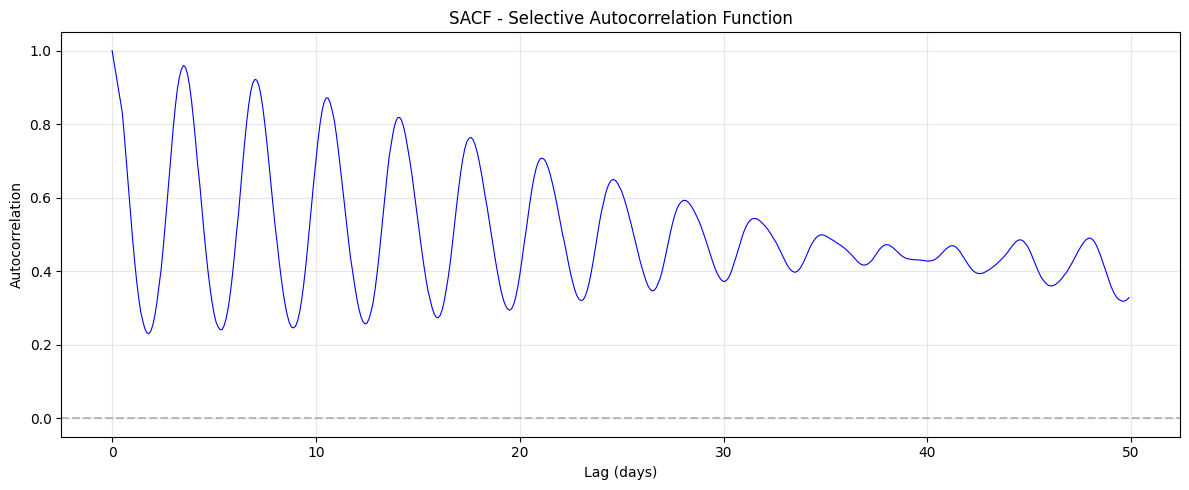

In [56]:
# # Plot the autocorrelation function
# plt.figure(figsize=(12, 5))
# plt.plot(lags, correlations, 'b-', linewidth=0.8)
# plt.xlabel('Lag (days)')
# plt.ylabel('Autocorrelation')
# plt.title('SACF - Selective Autocorrelation Function')
# plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
process_light_curve_sacf(light_curves,max_lag=3.6, lag_resolution=0.0001, 
                              min_period=3.0,)

In [57]:
# # Find the period from the highest peak in the ACF
# min_period_search = 1.0  # days - minimum period to consider

# # Find peaks in the correlation function
# peak_indices, peak_properties = find_peaks(correlations, height=0.1, distance=int(1.0/lag_resolution))

# # Filter peaks to those above minimum period
# valid_peaks = [(lags[i], correlations[i]) for i in peak_indices if lags[i] >= min_period_search]

# if valid_peaks:
#     # Sort by correlation strength (descending) and pick the highest
#     valid_peaks_sorted = sorted(valid_peaks, key=lambda x: x[1], reverse=True)
#     estimated_period = valid_peaks_sorted[0][0]
#     peak_correlation = valid_peaks_sorted[0][1]
    
#     print(f"Estimated Period: {estimated_period:.3f} days")
#     print(f"Peak correlation: {peak_correlation:.3f}")
#     print(f"\nAll detected peaks (sorted by correlation):")
#     for lag, corr in valid_peaks_sorted[:5]:
#         print(f"  {lag:.3f} days (correlation: {corr:.3f})")
# else:
#     print("No significant peaks found. Try adjusting parameters.")

Estimated Period: 3.500 days
Peak correlation: 0.960

All detected peaks (sorted by correlation):
  3.500 days (correlation: 0.960)
  7.000 days (correlation: 0.922)
  10.500 days (correlation: 0.872)
  14.100 days (correlation: 0.819)
  17.600 days (correlation: 0.764)


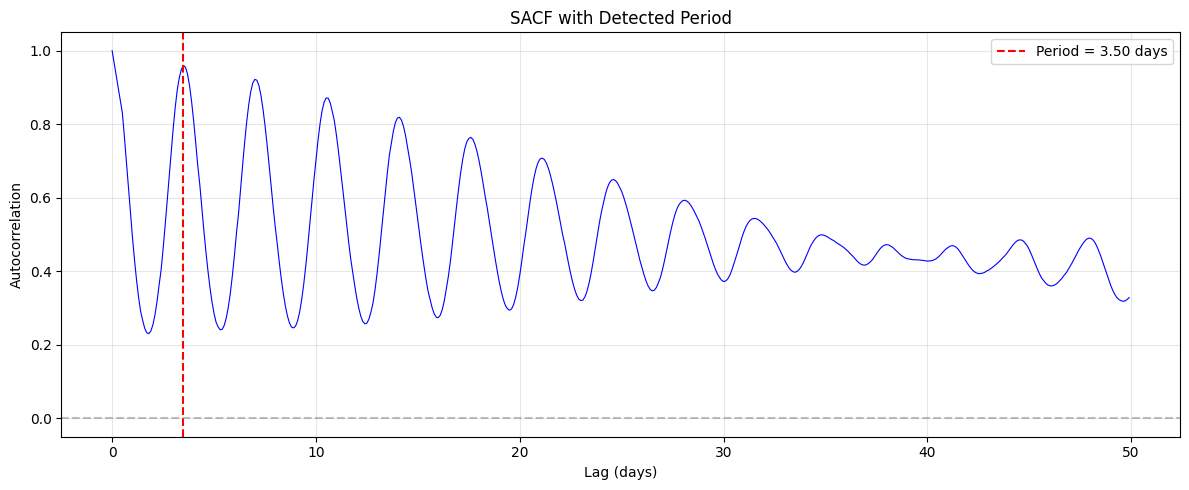

In [58]:
# # Plot ACF with detected period marked
# plt.figure(figsize=(12, 5))
# plt.plot(lags, correlations, 'b-', linewidth=0.8)
# if valid_peaks:
#     plt.axvline(x=estimated_period, color='r', linestyle='--', label=f'Period = {estimated_period:.2f} days')
#     plt.legend()
# plt.xlabel('Lag (days)')
# plt.ylabel('Autocorrelation')
# plt.title('SACF with Detected Period')
# plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

## Ground-Based Observation Simulation

Now let's simulate how this data would look if observed from the ground instead of space. Following the paper's methodology:
- **Night-time only**: 8 hours of observation per 24-hour period
- **Bad weather gaps**: Specific periods are masked to simulate cloudy nights
  - 18.5–22.5 days
  - 34.5–37.5 days
  - 48.5–52.5 days
  - 62.5–64.5 days
  - 76.5–81.5 days
  
This will drastically reduce the number of data points and create gaps in coverage.

In [59]:
def simulate_ground_observation_paper(lc):
    """
    Simulate ground-based observations following the paper's method:
    - Night-time: 8h of each 24h period
    - Bad weather at specific times: 18.5–22.5, 34.5–37.5, 48.5–52.5, 62.5–64.5, 76.5–81.5 d
    
    Parameters:
    -----------
    lc : light curve object
        Single Kepler light curve
    
    Returns:
    --------
    time_ground, flux_ground : arrays
        Simulated ground-based time and flux
    """
    time = lc.time.value.copy()
    flux = lc.flux.value.copy()
    
    # Remove NaNs from original
    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]
    
    # Get start time of this quarter
    time_start = time.min()
    
    # Convert to relative time (days since start of quarter)
    time_rel = time - time_start
    
    # Create mask for observable data
    observable_mask = np.ones(len(time), dtype=bool)
    
    # 1. Apply night-time only (8h per 24h period)
    # Assume night is the middle 8 hours of each day
    hours_per_day = 24.0
    night_duration = 8.0 / hours_per_day  # 8 hours = 1/3 day
    
    for day in range(int(time_rel.max()) + 1):
        # Night window: centered in each day
        night_start = day + (1 - night_duration) / 2
        night_end = night_start + night_duration
        
        # Mask out daytime (keep only night)
        daytime_mask = (time_rel >= day) & (time_rel < night_start) | \
                       (time_rel >= night_end) & (time_rel < day + 1)
        observable_mask &= ~daytime_mask
    
    # 2. Apply bad weather periods (relative to start of quarter)
    bad_weather_periods = [
        (18.5, 22.5),
        (34.5, 37.5),
        (48.5, 52.5),
        (62.5, 64.5),
        (76.5, 81.5)
    ]
    
    for start, end in bad_weather_periods:
        weather_mask = (time_rel >= start) & (time_rel <= end)
        observable_mask &= ~weather_mask
    
    # Keep only observable points
    time_ground = time[observable_mask]
    flux_ground = flux[observable_mask]
    
    return time_ground, flux_ground

Created 13 ground-based light curves


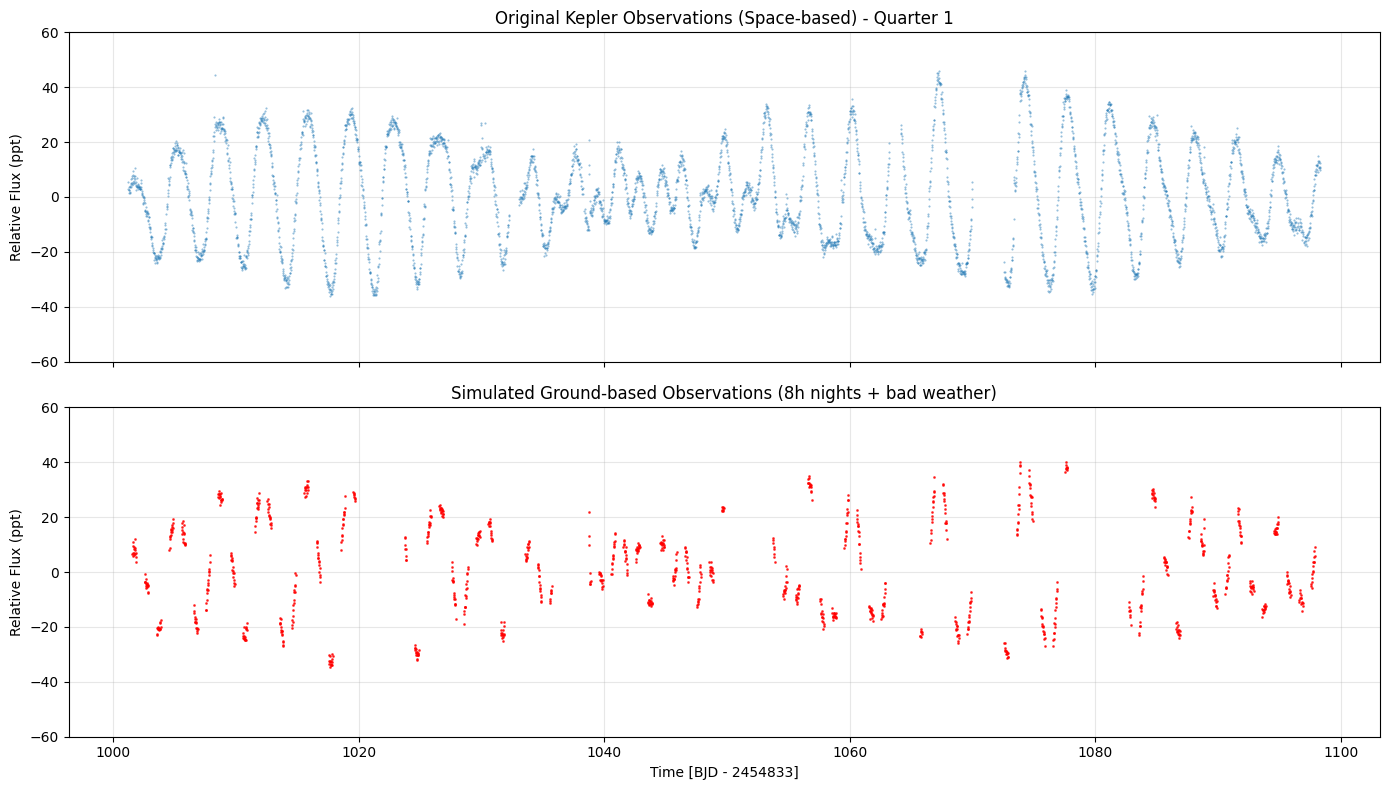


Quarter 1 comparison:
Original Kepler points: 4473
Ground-based points: 1224
Data retention: 27.4%


In [60]:
# Simulate ground-based observations for ALL quarters
ground_light_curves = []

for lc in light_curves:
    time_ground, flux_ground = simulate_ground_observation_paper(lc)
    
    # Create a simple object to store the data (similar to light curve structure)
    class GroundLC:
        def __init__(self, time, flux):
            self.time = type('obj', (object,), {'value': time})()
            self.flux = type('obj', (object,), {'value': flux})()
    
    ground_light_curves.append(GroundLC(time_ground, flux_ground))

print(f"Created {len(ground_light_curves)} ground-based light curves")

# Plot comparison for first quarter
lc = light_curves[0]
lc_ground = ground_light_curves[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Original Kepler data
time = lc.time.value
flux = lc.flux.value
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux_norm = (flux[mask] / np.nanmedian(flux[mask]) - 1) * 1e3

axes[0].plot(time, flux_norm, '.', markersize=1, alpha=0.5)
axes[0].set_ylabel('Relative Flux (ppt)')
axes[0].set_title('Original Kepler Observations (Space-based) - Quarter 1')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-60, 60)

# Ground-based simulation
time_ground = lc_ground.time.value
flux_ground = lc_ground.flux.value
flux_ground_norm = (flux_ground / np.nanmedian(flux_ground) - 1) * 1e3

axes[1].plot(time_ground, flux_ground_norm, '.', markersize=2, alpha=0.7, color='red')
axes[1].set_xlabel('Time [BJD - 2454833]')
axes[1].set_ylabel('Relative Flux (ppt)')
axes[1].set_title('Simulated Ground-based Observations (8h nights + bad weather)')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-60, 60)

plt.tight_layout()
plt.show()

print(f"\nQuarter 1 comparison:")
print(f"Original Kepler points: {len(time)}")
print(f"Ground-based points: {len(time_ground)}")
print(f"Data retention: {len(time_ground)/len(time)*100:.1f}%")

In [61]:
ground_based_time_periods = process_light_curve_sacf(ground_light_curves, )

13
